In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0
%pylab inline
%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from pathlib import Path
import pickle
import pandas as pd
from tqdm import tqdm
import networkx as nx
from allensdk.core.cell_types_cache import CellTypesCache

In [3]:
from ssl_neuron.data.data_utils import connect_graph, remove_axon, rotate_cell
from ssl_neuron.utils import neighbors_to_adjacency, plot_neuron

In [4]:
data_path = "/nfs/data8/chuyu/data/20230422_160839/connectome/swc/skeletons_scale2_swc_healed"
file_list = list(Path(data_path).glob("*.swc")) 

# each file has name like neuron_14431507_scale2.swc, extract the neuron ids
neuron_ids = [int(f.stem.split("_")[1]) for f in file_list]

In [5]:
len(neuron_ids)

235

#### Preprocess cells

In [112]:
def read_swc_file(file_path, correction =True):
    """Read SWC file and return morphology as a pandas DataFrame."""
    columns = ['id', 'type', 'x', 'y', 'z', 'radius', 'parent']
    morphology = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns)
    if correction:
        # remove the 1st row
        morphology = morphology.iloc[1:].reset_index(drop=True)
        # set id to id - 1, parent to parent - 1
        morphology['id'] = morphology['id'] - 1
        morphology['parent'] = morphology['parent'] - 1
    return morphology

In [141]:
which_cell = 0
cell_id = neuron_ids[which_cell]
path = Path('./skeletons/', str(cell_id))
path.mkdir(parents=True, exist_ok=True)
# read from swc file
file_name  = file_list[which_cell]
morphology = read_swc_file(file_name, correction=False)

In [142]:
file_name

PosixPath('/nfs/data8/chuyu/data/20230422_160839/connectome/swc/skeletons_scale2_swc_healed/neuron_8140431_scale2_healed.swc')

In [143]:
morphology

,id,type,x,y,z,radius,parent
0,0,1,147313.2324,206046.7188,54094.18335,10.0,-1
1,1,0,202280.0000,221160.0000,34800.00000,-1.0,0
2,2,0,202320.0000,221200.0000,34850.00000,-1.0,1
3,3,0,202360.0000,221240.0000,34850.00000,-1.0,2
4,4,0,202400.0000,221240.0000,34900.00000,-1.0,3
...,...,...,...,...,...,...,...
13799,13799,0,222680.0000,241680.0000,76650.00000,-1.0,13798
13800,13800,0,222640.0000,241720.0000,76500.00000,-1.0,13797
13801,13801,0,222680.0000,241680.0000,76450.00000,-1.0,13800
13802,13802,0,222720.0000,241640.0000,76400.00000,-1.0,13801


In [144]:
# ensure integer ids if needed
morphology['id'] = morphology['id'].astype(int)
morphology['parent'] = morphology['parent'].astype(int)

# build map: parent_id -> [child_id1, child_id2, ...]
children_map = (morphology.loc[morphology['parent'] != -1]
                           .groupby('parent')['id']
                           .apply(list)
                           .to_dict())

# assign children lists to each row; use .apply to get fresh lists per row
morphology['children'] = morphology['id'].apply(lambda _id: list(children_map.get(_id, [])))

In [145]:
morphology

,id,type,x,y,z,radius,parent,children
0,0,1,147313.2324,206046.7188,54094.18335,10.0,-1,[1]
1,1,0,202280.0000,221160.0000,34800.00000,-1.0,0,[2]
2,2,0,202320.0000,221200.0000,34850.00000,-1.0,1,[3]
3,3,0,202360.0000,221240.0000,34850.00000,-1.0,2,[4]
4,4,0,202400.0000,221240.0000,34900.00000,-1.0,3,[5]
...,...,...,...,...,...,...,...,...
13799,13799,0,222680.0000,241680.0000,76650.00000,-1.0,13798,[]
13800,13800,0,222640.0000,241720.0000,76500.00000,-1.0,13797,[13801]
13801,13801,0,222680.0000,241680.0000,76450.00000,-1.0,13800,[13802]
13802,13802,0,222720.0000,241640.0000,76400.00000,-1.0,13801,[13803]


In [146]:
# Process graph.
neighbors = {}
idx2node = {}
for i, item in enumerate(morphology.to_dict(orient='records')):
    # Get node features.
    sec_type = [0, 0, 0, 0]
    sec_type[item['type'] - 1] = 1
    feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
    idx2node[i] = feat
    
    # Get neighbors.
    neighbors[i] = set(item['children'])
    # neighbors[i] = set()
    if item['parent'] >= 0 :
    # if item['parent'] != -1:
        neighbors[i].add(item['parent'])

features = np.array(list(idx2node.values()))

In [147]:
len(neighbors.keys())

13804

In [148]:
# Test if graph is connected.
adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
G = nx.Graph(adj_matrix)
if nx.number_connected_components(G) > 1:
    adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)

assert len(neighbors) == len(adj_matrix)

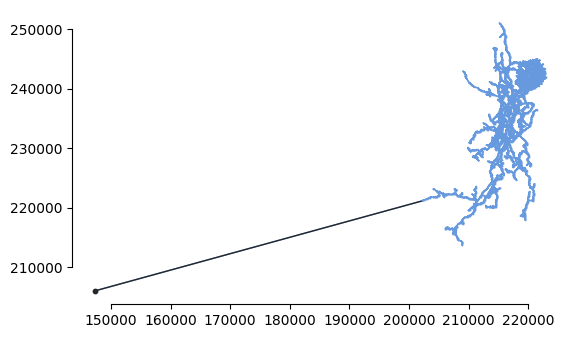

In [149]:
plot_neuron(neighbors, features)

In [ ]:
for cell_id in tqdm(cell_ids):
    path = Path('./skeletons/', str(cell_id))
    path.mkdir(parents=True, exist_ok=True)

    morphology = ctc.get_reconstruction(cell_id) 
    
    # Rotate respecitve to pia.
    morphology = rotate_cell(cell_id, morphology, df)

    # Get soma coordinates.
    soma = morphology.soma
    soma_pos = np.array([soma['x'], soma['y'], soma['z']])
    soma_id = soma['id']

    # Process graph.
    neighbors = {}
    idx2node = {}
    for i, item in enumerate(morphology.compartment_list):
        # Get node features.
        sec_type = [0, 0, 0, 0]
        sec_type[item['type'] - 1] = 1
        feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
        idx2node[i] = feat
        
        # Get neighbors.
        neighbors[i] = set(item['children'])
        if item['parent'] != -1:
            neighbors[i].add(item['parent'])

    features = np.array(list(idx2node.values()))
    
    assert ~np.any(np.isnan(features))
    
    # Normalize soma position to origin.
    norm_features = features.copy()
    norm_features[:, :3] = norm_features[:, :3] - soma_pos
    
    # Test if graph is connected.
    adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
    G = nx.Graph(adj_matrix)
    if nx.number_connected_components(G) > 1:
        adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)
        
    assert len(neighbors) == len(adj_matrix)

    # Remove axons.
    neighbors, norm_features, soma_id = remove_axon(neighbors, norm_features, int(soma_id))

    assert len(neighbors) == len(norm_features)
    assert ~np.any(np.isnan(norm_features))

    np.save(Path(path, 'features'), norm_features)
    with open(Path(path, 'neighbors.pkl'), 'wb') as f:
        pickle.dump(dict(neighbors), f, pickle.HIGHEST_PROTOCOL)

100%|██████████| 430/430 [31:26<00:00,  4.39s/it]
